# 02 Clinical Metadata EDA

Metadata-only EDA: demographics and clinical scale scores for the 52 MODMA/Lanzhou subjects (audio signal quality is covered separately in [`03_audio_signal_eda.ipynb`](03_audio_signal_eda.ipynb)). Full schema/background is in [`DATA_CONTEXT.md`](DATA_CONTEXT.md).

Primary questions:
- What does the metadata schema actually contain, and what's missing from it (this dataset has no HAMD)?
- Are there missing values?
- How do PHQ-9 and the five secondary scales (CTQ-SF, LES, SSRS, GAD-7, PSQI) distribute by class?
- Which scales separate MDD from HC, and which of those are usable model features versus leaky-by-construction?
- Do demographics (age, gender, education) show class imbalance that could confound acoustic features?

Input: `backend/data/processed/subjects_labeled.csv` (from `01_dataset_audit.ipynb`).

In [1]:
import sys
from pathlib import Path

_nb_dir = Path("backend/notebooks") if Path("backend/notebooks").exists() else Path.cwd()
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import pandas as pd
from _eda_utils import bootstrap_project_paths, load_processed, plot_by_label, mannwhitney_effect_size

PROJECT_ROOT = bootstrap_project_paths()

from mendxai.core.config import config
from mendxai.ml.data_loader import DataLoader

try:
    subjects_df = load_processed("subjects_labeled.csv")
except FileNotFoundError:
    print("subjects_labeled.csv not found — recomputing via DataLoader (run 01_dataset_audit.ipynb to cache it)")
    subjects_df = DataLoader().load_metadata()
    subjects_df["subject_id"] = subjects_df["subject id"].apply(lambda x: str(int(x)).zfill(8))

display(subjects_df.head())
print(f"\nShape: {subjects_df.shape}")

Loaded 52 rows from /Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/processed/subjects_labeled.csv


,subject_id,n_wav_files,n_valid_indices,subject id,type,age,gender,education（years）,PHQ-9,CTQ-SF,LES,SSRS,GAD-7,PSQI
0,02010001,29,29,2010001,MDD,28,M,9,21,51,-2,18,10,5
1,02010002,29,29,2010002,MDD,18,F,12,23,77,-143,31,18,12
2,02010003,29,29,2010003,MDD,35,M,9,20,44,-100,28,16,15
3,02010004,29,29,2010004,MDD,25,F,19,12,53,-44,38,13,11
4,02010005,29,29,2010005,MDD,20,M,16,19,49,-3,28,11,5



Shape: (52, 14)


In [2]:
SCALE_INFO = {
    "PHQ-9": "Patient Health Questionnaire (depression severity), range 0-27. PHQ-9 >= 5 was required for MDD inclusion in this cohort — see caveat below.",
    "CTQ-SF": "Childhood Trauma Questionnaire, Short Form",
    "LES": "Life Event Scale",
    "SSRS": "Social Support Research Scale",
    "GAD-7": "Generalized Anxiety Disorder scale, range 0-21",
    "PSQI": "Pittsburgh Sleep Quality Index",
}

print("Scale glossary (see DATA_CONTEXT.md section 4):")
for scale, desc in SCALE_INFO.items():
    print(f"  {scale}: {desc}")

print("\nNOTE: this dataset has NO HAMD column — only PHQ-9 is used for depression severity/inclusion.")
print("Columns present:", subjects_df.columns.tolist())
print("\nDtypes:")
display(subjects_df.dtypes)

Scale glossary (see DATA_CONTEXT.md section 4):
  PHQ-9: Patient Health Questionnaire (depression severity), range 0-27. PHQ-9 >= 5 was required for MDD inclusion in this cohort — see caveat below.
  CTQ-SF: Childhood Trauma Questionnaire, Short Form
  LES: Life Event Scale
  SSRS: Social Support Research Scale
  GAD-7: Generalized Anxiety Disorder scale, range 0-21
  PSQI: Pittsburgh Sleep Quality Index

NOTE: this dataset has NO HAMD column — only PHQ-9 is used for depression severity/inclusion.
Columns present: ['subject_id', 'n_wav_files', 'n_valid_indices', 'subject id', 'type', 'age', 'gender', 'education（years）', 'PHQ-9', 'CTQ-SF', 'LES', 'SSRS', 'GAD-7', 'PSQI']

Dtypes:


subject_id            str
n_wav_files         int64
n_valid_indices     int64
subject id          int64
type                  str
age                 int64
gender                str
education（years）    int64
PHQ-9               int64
CTQ-SF              int64
LES                 int64
SSRS                int64
GAD-7               int64
PSQI                int64
dtype: object

In [3]:
missing = subjects_df.isna().sum()
print("Missing values per column:")
display(missing)
assert missing.sum() == 0, "Unexpected missing values — investigate before proceeding"
print("\nConfirmed: zero missing values across all columns.")

Missing values per column:


subject_id          0
n_wav_files         0
n_valid_indices     0
subject id          0
type                0
age                 0
gender              0
education（years）    0
PHQ-9               0
CTQ-SF              0
LES                 0
SSRS                0
GAD-7               0
PSQI                0
dtype: int64


Confirmed: zero missing values across all columns.


/var/folders/_9/jr3ydm_n38gd1fw87ws1gb600000gn/T/ipykernel_40874/3852512410.py:8: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_9/jr3ydm_n38gd1fw87ws1gb600000gn/T/ipykernel_40874/3852512410.py:8: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/vishalkarda/Documents/Projects/mendx.ai/.nvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vishalkarda/Documents/Projects/mendx.ai/.nvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


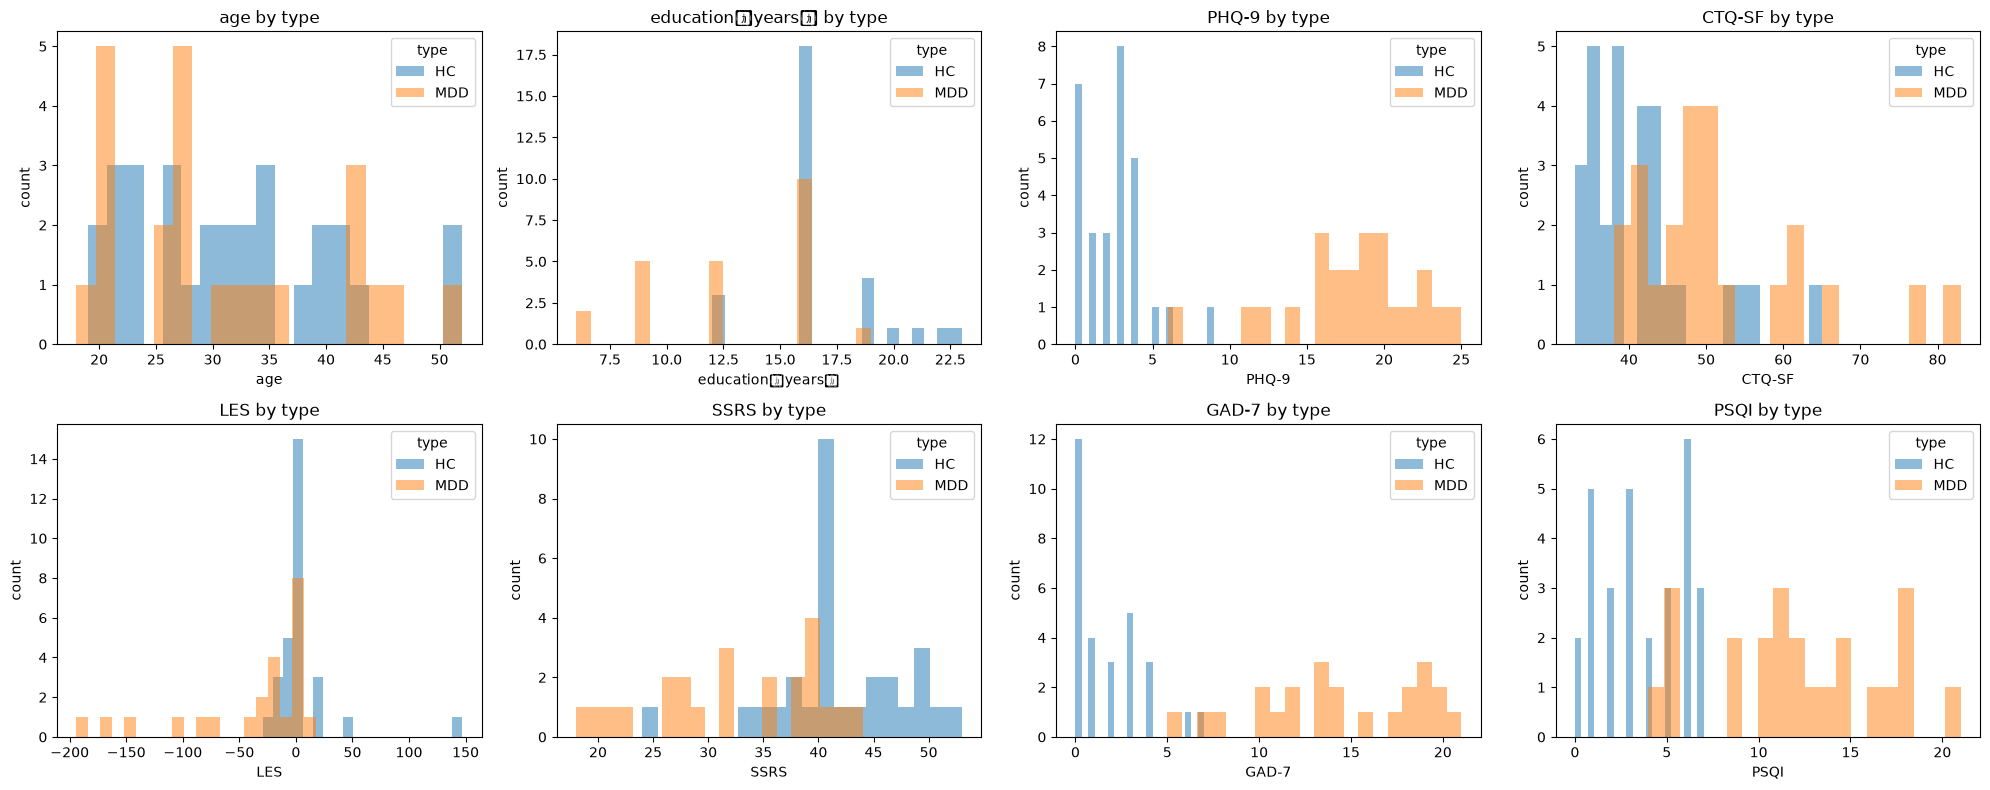

In [4]:
import matplotlib.pyplot as plt

NUMERIC_SCALES = ["age", "education（years）", "PHQ-9", "CTQ-SF", "LES", "SSRS", "GAD-7", "PSQI"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for col, ax in zip(NUMERIC_SCALES, axes.flat):
    plot_by_label(subjects_df, col, label_col="type", ax=ax)
plt.tight_layout()
plt.show()

In [5]:
separation_results = [mannwhitney_effect_size(subjects_df, col) for col in NUMERIC_SCALES]
separation_df = pd.DataFrame(separation_results).sort_values("cohens_d", key=abs, ascending=False)
display(separation_df)

print(
    "\nCAVEAT: PHQ-9 >= 5 was a REQUIRED inclusion criterion for the MDD group (see DATA_CONTEXT.md "
    "section 2), so PHQ-9 trivially separates classes by construction. Its strong separation here is "
    "a diagnostic-validity check, not evidence of a usable, non-leaky model feature."
)

,feature,n_a,n_b,mean_a,mean_b,u_stat,p_value,cohens_d
2,PHQ-9,23,29,18.086957,2.517241,665.5,8.690847e-10,4.656221
6,GAD-7,23,29,14.304348,1.724138,664.5,8.589942e-10,3.743504
7,PSQI,23,29,12.130435,3.655172,622.5,9.779295e-08,2.374181
5,SSRS,23,29,32.434783,42.068966,109.0,3.483211e-05,-1.415716
1,education（years）,23,29,12.869565,16.758621,150.5,2.410509e-04,-1.227474
3,CTQ-SF,23,29,51.826087,41.517241,543.0,1.156369e-04,1.086340
4,LES,23,29,-40.695652,5.137931,153.5,8.721407e-04,-1.017498
0,age,23,29,30.913043,31.551724,316.0,7.538040e-01,-0.068735



CAVEAT: PHQ-9 >= 5 was a REQUIRED inclusion criterion for the MDD group (see DATA_CONTEXT.md section 2), so PHQ-9 trivially separates classes by construction. Its strong separation here is a diagnostic-validity check, not evidence of a usable, non-leaky model feature.


/Users/vishalkarda/Documents/Projects/mendx.ai/.nvenv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/vishalkarda/Documents/Projects/mendx.ai/.nvenv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/vishalkarda/Documents/Projects/mendx.ai/.nvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vishalkarda/Documents/Projects/mendx.ai/.nvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


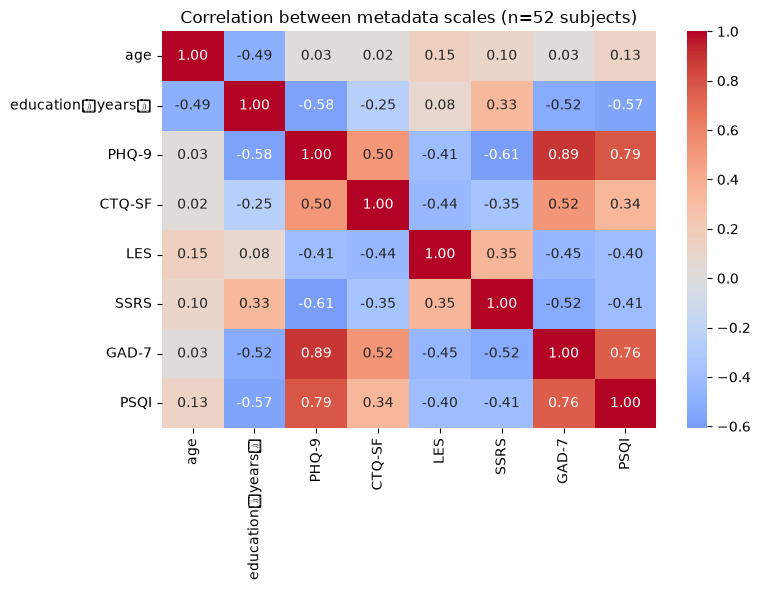

In [6]:
import seaborn as sns

corr = subjects_df[NUMERIC_SCALES].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between metadata scales (n=52 subjects)")
plt.tight_layout()
plt.show()

In [7]:
print("Gender x type crosstab (context for the companion paper's separately-reported")
print("male/female accuracy of 75.8%/68.5% — see DATA_CONTEXT.md section 7):")
display(pd.crosstab(subjects_df["gender"], subjects_df["type"]))

print("\nPHQ-9 by gender x type:")
display(subjects_df.groupby(["gender", "type"])["PHQ-9"].describe())

Gender x type crosstab (context for the companion paper's separately-reported
male/female accuracy of 75.8%/68.5% — see DATA_CONTEXT.md section 7):


type,HC,MDD
gender,,
F,9,7
M,20,16



PHQ-9 by gender x type:


count       mean       std   min    25%   50%   75%   max
gender type                                                           
F      HC      9.0   2.111111  2.204793   0.0   0.00   3.0   3.0   6.0
       MDD     7.0  18.142857  5.145502  11.0  14.00  20.0  22.5  23.0
M      HC     20.0   2.700000  2.105132   0.0   1.00   3.0   4.0   9.0
       MDD    16.0  18.062500  4.281258   6.0  16.75  18.5  20.0  25.0

## Summary

- Schema: 11 real columns (demographics + 6 clinical scales). No HAMD in this dataset — PHQ-9 only.
- Zero missing values confirmed across all columns (hard-asserted above).
- Class-separation ranking (by |Cohen's d|): **PHQ-9** (d=4.66) > **GAD-7** (d=3.74) > **PSQI** (d=2.37) > SSRS (d=-1.42) > education (d=-1.23) > CTQ-SF (d=1.09) > LES (d=-1.02) > age (d=-0.07, not separating). PHQ-9 is **excluded as a candidate model feature** — it was part of the MDD inclusion criterion (PHQ-9≥5), so using it would leak the label definition itself rather than reflect a genuine acoustic/behavioral signal.
- After excluding PHQ-9, **GAD-7 and PSQI show the strongest separation** (both p<1e-6) — worth cross-referencing against acoustic features in `04_feature_baseline_eda.ipynb`, though they're still self-reported clinical scales, not acoustic signal.
- **Age does not separate classes** (d=-0.07, p=0.75) — reassuring, since a strong age imbalance would confound any acoustic-feature comparison (age affects voice independent of depression status).
- Gender is imbalanced (36 M / 16 F: 20 HC/16 MDD male, 9 HC/7 MDD female) — worth treating as a potential confound for acoustic features, and consistent with why the companion paper reports gender-split accuracy (75.8% male / 68.5% female).
- Small n=52: p-values here are exploratory signals, not confirmatory tests.